# Limpieza del dataset

El objetivo de este notebook es tratar los datos de nuestro dataset inicial,
comprobando los datos de los que disponemos, haciendo transformaciones en las
columnas para homogeneizarlas con los datos scrapeados y verificar que los datos son correctos, corrigiendo los outliers si fuera necesario.

## Índice

1. [Carga y análisis del CSV original](#1-carga-y-análisis-del-csv-original)

2. [Limpieza de datos](#2-limpieza-de-datos)
   1. [Eliminamos duplicados y tratamos valores nulos](#21-eliminamos-duplicados-y-tratamos-valores-nulos)
   2. [Corregimos datos incorrectos](#22-corregimos-datos-incorrectos)

3. [Unificación de formatos](#3-unificacion-de-formatos)

4. [Normalización de texto](#4-normalizacion-de-texto)
   1. [Conversión a minúsculas y eliminación de tildes, acentos y caracteres especiales](#41-conversion-a-minusculas-y-eliminacion-de-tildes-acentos-y-caracteres-especiales)
   2. [Columna "workday"](#42-columna-workday)
   3. [Columna "remote"](#43-columna-remote)
   4. [Unificación de las categorías laborales](#44-unificacion-de-las-categorias-laborales)

5. [Creación y eliminación de columnas](#5-creacion-y-eliminacion-de-columnas)
   1. [Position_level](#51-position_level)
   2. [Modificación de datos de país](#52-modificacion-de-datos-de-pais)
   3. [Annual salary](#53-annual-salary)
   4. [Creación de la columna "provincia"](#54-creacion-de-la-columna-provincia)
   5. [Eliminación de columnas innecesarias](#55-eliminacion-de-columnas-innecesarias)

6. [Corrección de outliers](#6-correccion-de-outliers)
   1. [Corrección de sueldos más bajos](#61-correccion-de-sueldos-mas-bajos)
   2. [Corrección de sueldos más altos](#62-correccion-de-sueldos-mas-altos)

7. [Análisis exploratorio de datos (EDA)](#7-analisis-exploratorio-de-datos-eda)
   1. [Media, mediana, desviación estándar y outliers](#71-media-mediana-desviacion-estandar-y-outliers)
   2. [Distribución de salarios y por sector](#72-distribucion-de-salarios-y-por-sector)
   3. [Gráficos de barras y temporales](#73-graficos-de-barras-y-temporales)

8. [Preguntas del caso de estudio](#8-preguntas-del-caso-de-estudio)
   1. [Número de ofertas en el dataset](#81-numero-de-ofertas-en-el-dataset)
   2. [Sueldo medio](#82-sueldo-medio)
   3. [Trabajos mejor pagados y dónde](#83-trabajos-mejor-pagados-y-donde)
   4. [Empresas en ambos datasets](#84-empresas-en-ambos-datasets)
   5. [Empresas con mejores salarios](#85-empresas-con-mejores-salarios)
   6. [Empresas con más publicaciones y sector (datos scrapeados)](#86-empresas-con-mas-publicaciones-y-sector-datos-scrapeados)
   7. [Estacionalidad](#87-estacionalidad)
   8. [Ciudades o regiones con más ofertas](#88-ciudades-o-regiones-con-mas-ofertas)
   9. [Comparativas entre ambos datasets](#89-comparativas-entre-ambos-datasets)

9. [Preparación final para la exportación del CSV](#9-preparacion-final-para-la-exportacion-del-csv)
   1. [Eliminación de columnas innecesarias](#91-eliminacion-de-columnas-innecesarias)
   2. [Exportación del CSV](#92-exportacion-del-csv)

## 1.Carga y análisis del CSV original

In [ ]:
# Importamos libreria pandas y numpy
import pandas as pd
import numpy as np

In [ ]:
# Cargamos el archivo desde Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Subimos el archivo a nuestro proyecto

# ruta = '/content/drive/MyDrive/Oferta-empleos(1)/ofertas-empleo (1).csv'
# df = pd.read_csv(ruta)
 # Damos acceso para que todos puedan entrar por la carpeta del drive compartida.
CSV_ID = "1-k2lReDuq5A2hUukC6XXWrf4ZnQCvW-a"

url = f"https://drive.google.com/uc?export=download&id={CSV_ID}"

df = pd.read_csv(url, encoding="utf-8")



In [ ]:
# Obtenemos las columnas del df y las convertirmos en una lista para visualizarlas claramente
df.columns.values.tolist()

['country_code',
 'title',
 'job_category',
 'description',
 'company_name',
 'city',
 'contract_type',
 'workday',
 'salary_min',
 'salary_max',
 'salary_period',
 'salary_currency',
 'salary_type',
 'remote',
 'publish_date']

In [ ]:
# Mostramos las primeras 3 filas del DataFrame para tener una vista previa de los datos
df.head(3)

,country_code,title,job_category,description,company_name,city,contract_type,workday,salary_min,salary_max,salary_period,salary_currency,salary_type,remote,publish_date
0,es,Técnico Gestión de la Demanda,Informática y telecomunicaciones,-Definición de roles y escenarios\r\n - D...,Atento España - Estructura,Madrid,Contrato indefinido,Jornada completa,NaN,NaN,NaN,NaN,NaN,Híbrido,2022-07-12
1,es,Java - SpringBoot - Proyecto estable - Teletra...,Informática y telecomunicaciones,"Desde AgioGlobal Technology, nos encontramos e...",AGIO GLOBAL TECHNOLOGY,Madrid,Contrato indefinido,Jornada completa,40000.0,45000.0,YEAR,EUR,GROSS,Solo teletrabajo,2022-07-12
2,es,Consultor SAP Hana Ingles Alto (Remoto),Informática y telecomunicaciones,AirON compañia de innovacion servicios tecnolo...,AIRON Sistemas S.L.,Madrid,Contrato indefinido,Jornada completa,27000.0,30000.0,YEAR,EUR,GROSS,Solo teletrabajo,2022-07-12


In [ ]:
# Imprime la forma del DataFrame, mostrando el número de filas y columnas
df.shape

(10000, 15)

In [ ]:
# Muestra los tipos de datos de cada columna en el DataFrame
print(f">>> Tipo de columnas:\n{df.dtypes}\n")

>>> Tipo de columnas:
country_code        object
title               object
job_category        object
description         object
company_name        object
city                object
contract_type       object
workday             object
salary_min         float64
salary_max         float64
salary_period       object
salary_currency     object
salary_type         object
remote              object
publish_date        object
dtype: object



In [ ]:
# Proporciona un resumen conciso del DataFrame
# incluyendo la cantidad de valores no nulos y el tipo de dato por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     10000 non-null  object 
 1   title            10000 non-null  object 
 2   job_category     10000 non-null  object 
 3   description      10000 non-null  object 
 4   company_name     10000 non-null  object 
 5   city             9999 non-null   object 
 6   contract_type    4647 non-null   object 
 7   workday          4647 non-null   object 
 8   salary_min       4286 non-null   float64
 9   salary_max       4162 non-null   float64
 10  salary_period    6988 non-null   object 
 11  salary_currency  6988 non-null   object 
 12  salary_type      1635 non-null   object 
 13  remote           4053 non-null   object 
 14  publish_date     10000 non-null  object 
dtypes: float64(2), object(13)
memory usage: 1.1+ MB


In [ ]:
# Genera estadísticas descriptivas que resumen
# la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos
df.describe()

,salary_min,salary_max
count,4.286000e+03,4.162000e+03
mean,6.034396e+04,8.619583e+04
std,1.511560e+05,1.823247e+05
min,1.200000e+01,1.200000e+01
25%,2.500000e+04,3.202525e+04
50%,3.600000e+04,4.800000e+04
75%,6.318850e+04,9.390825e+04
max,7.500000e+06,7.501000e+06


## 2.Limpieza de datos

### 2.1 Eliminamos duplicados y tratamos valores nulos

In [ ]:
# ELIMINACION DUPLICADOS

# En esta sección identificamos y eliminamos filas duplicadas en el dataset.
# Se analizan tanto duplicados exactos como duplicados que sean la misma oferta.

In [ ]:
# Calculo el número de filas completamente duplicadas
df.duplicated().sum()

np.int64(0)

In [ ]:
# Confirmo que no tengo duplicados igual
df[df.duplicated()]

# Al saltar solo el nombre de las columnas confirmo que no tengo filas duplicadas exactas
# El resultado es un df en el que NO tiene duplicados exactos, NO se han elimando filas en esta fase

,country_code,title,job_category,description,company_name,city,contract_type,workday,salary_min,salary_max,salary_period,salary_currency,salary_type,remote,publish_date


In [ ]:
# Buscamos si tenemos ofertas que sus filas no sean exactamente igual pero si esten repetidas.

revision_cols = ['title', 'company_name', 'city', 'publish_date']  # Revisamos estas columnas, porque si coincide seria la misma oferta repetida

df[df.duplicated(subset=revision_cols, keep=False)] # Buscamos las filas repetidas de las columnas seleccionadas en la lista revision_cols


# Consideramos que una oferta es única si coincide en:
# ['title', 'company_name', 'city', 'publish_date'].

# Vemos varias ofertas que coinciden en todos los campos excepto en ('contract_type'y 'remote'). Mantendremos solo una fila de estas ofertas.


,country_code,title,job_category,description,company_name,city,contract_type,workday,salary_min,salary_max,salary_period,salary_currency,salary_type,remote,publish_date
17,es,Técnico/a Microinformático,Informática y telecomunicaciones,¡Te invitamos a formar parte de nuestro equipo...,Sermicro,Madrid,Contrato otros contratos,Jornada completa,NaN,NaN,NaN,NaN,NaN,Presencial,2022-07-12
94,es,Técnico/a Microinformático,Informática y telecomunicaciones,¡Te invitamos a formar parte de nuestro equipo...,Sermicro,Madrid,Contrato fijo discontinuo,Jornada completa,NaN,NaN,NaN,NaN,NaN,Presencial,2022-07-12
6171,es,Network & Security Operator,Informática y telecomunicaciones,"SEIDOR, multinacional española en plena expans...",Grupo Seidor,Barcelona,Contrato indefinido,Jornada completa,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-03
6172,es,Network & Security Operator,Informática y telecomunicaciones,"SEIDOR, multinacional española en plena expans...",Grupo Seidor,Barcelona,Contrato indefinido,Jornada completa,NaN,NaN,NaN,NaN,NaN,Presencial,2022-08-03


In [ ]:
# Eliminamos duplicados con ofertas repetidas en los campos('title', 'company_name', 'city', 'publish_date').

# Conservaremos la segunda aparicion de las ofertas por consideras datos mas completos

df = df.drop_duplicates(subset=revision_cols, keep='last')

In [ ]:
# Buscamos cuantos valores nulos tenemos en cada columna del df:
df.isnull().sum()

,0
country_code,0
title,0
job_category,0
description,0
company_name,0
city,1
contract_type,5353
workday,5353
salary_min,5712
salary_max,5836


In [ ]:
# Hacemos limpieza de ciertas columnas que tiene nulos sustituyendolo por 'No publicado'

df['contract_type'] = df['contract_type'].fillna('No publicado')
df['workday'] = df['workday'].fillna('No publicado')
df['remote'] = df['remote'].fillna('No publicado')

# Las columnas seleccionadas es normal que no se publiquen estos datos en las ofertas de las empresas
# Al mantener las columnas con otra categoria 'No publicado', nos da otra información util:
#  -Mantenemos toda la informacion
#  -Nueva categoria dentro de las columna
#  -Mejor analisis con la información mas completa
#  -Mejor visualización posterior en POWER BI y otros analisis cuando hagamos webscraping


# La columna 'city' tiene un nulo que no tiene sentido. Elminamos dicha fila que no afecta al análisis para que despues
# no tengamos problemas si queremos agrupar por ciudades en el EDA o en el POWER BI entre otras cosas.

df = df.dropna(subset=['city'])

df.isnull().sum()

,0
country_code,0
title,0
job_category,0
description,0
company_name,0
city,0
contract_type,0
workday,0
salary_min,5711
salary_max,5835


### 2.2 Corregimos datos incorrectos

In [ ]:
# CORREGIR DATOS INCORRECTOS
# Comprobamos los salarios

# Ni el salario minimo ni el maximo puede ser menor que cero

df[(df['salary_min'] < 0) |(df['salary_max']< 0)]


# Como el df aparece vacío, comprobamos que los salarios estan correctos segun estas comprobaciones

,country_code,title,job_category,description,company_name,city,contract_type,workday,salary_min,salary_max,salary_period,salary_currency,salary_type,remote,publish_date


In [ ]:
# El salario maximo no puede ser menos que el salario minimo

df[df['salary_max'] < df['salary_min']] # Como sales el df vacio comprobamos que los salarios estan correctos segun estas comprobaciones

,country_code,title,job_category,description,company_name,city,contract_type,workday,salary_min,salary_max,salary_period,salary_currency,salary_type,remote,publish_date


## 3.Unificacion de formatos

In [ ]:
# En este bloque vamos a tratar la unificación de formatos para estandarizar el data set mediante la corrección de formatos (fechas,salarios y
# eliminación de símbolos)

# Convertimos la columna a un tipo fecha indicando que está en formato americano
df["publish_date"] = pd.to_datetime(df["publish_date"], dayfirst=False)
# pd.to_datetime() convierte una columna de texto en objetos de fecha (datetime).dayfirst=False indica que el primer número no es el día, sino el mes.

In [ ]:
# Formatos de salario

# En algunas columnas puede aparecer algo como "30.000 €"
# Queremos dejarlo como "30000" (sin espacios ni símbolo)

# Primero, eliminamos símbolos € y espacios
df["salary_min"] = df["salary_min"].astype(str).str.replace("€", "", regex=False).str.strip()
df["salary_max"] = df["salary_max"].astype(str).str.replace("€", "", regex=False).str.strip()

# Convertimos a número directamente (NaN si no se puede)
df["salary_min"] = pd.to_numeric(df["salary_min"], errors='coerce')
df["salary_max"] = pd.to_numeric(df["salary_max"], errors='coerce')

# Redondeamos para quitar posibles decimales y convertimos a Int64
df["salary_min"] = df["salary_min"].round().astype("Int64")
df["salary_max"] = df["salary_max"].round().astype("Int64")


# No surge el siguiente problema respecto a las columnas de salarios y es
# que en Pandas no se puede tener una columna con enteros y NaN al mismo tiempo usando el tipo int
# Lo hemos solucionado usando el tipo Int64 de Pandas, que permite enteros y valores nulos (<NA>). Así no vemos .0.

In [ ]:
# Aquí quitamos:
# - Saltos de línea (\n)
# - Tabulaciones (\t)
# - Comillas dobles (")
# - Comillas simples (')
# - Espacios repetidos

columnas_texto = [    "title", "job_category", "description", "company_name",
    "city", "contract_type", "workday", "remote"]

for col in columnas_texto:

    # Convertimos la columna a texto por si hay valores no textuales
    df[col] = df[col].astype(str)

    # Quitamos saltos de línea
    df[col] = df[col].str.replace("\n", " ", regex=False)

    # Quitamos tabulaciones
    df[col] = df[col].str.replace("\t", " ", regex=False)

    # Quitamos comillas dobles y simples
    df[col] = df[col].str.replace('"', "", regex=False)
    df[col] = df[col].str.replace("'", "", regex=False)

    # Quitamos espacios repetidos dejando solo uno
    df[col] = df[col].str.replace("  ", " ", regex=False)

    # Quitamos espacios al principio y al final
    df[col] = df[col].str.strip()

## 4.Normalizacion de texto

### 4.1 Conversión a minúsculas y eliminación tildes, acentos y caracteres especiales

In [ ]:
# En este bloque estandarizamos todas las columnas de texto convirtiéndolas a minúsculas
# y eliminando tildes, acentos y caracteres especiales.
# Función homogeneizar
# En esta parte nos hemos centrado en poner todo el texto a minúscula y quitar los acentos
import re # Módulo de expresiones regulares, que nos permite trabajar con patrones de textos complejos.

def normalizar_texto(texto):
    if not isinstance(texto, str):
        return texto

    texto = texto.lower()

    # Reemplazar acentos
    acentos = {
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "ü": "u"
    }
    for a, s in acentos.items():
        texto = texto.replace(a, s)

    return texto

In [ ]:
# Aplicamos la normalización a todas las columnas de texto del df.
# Convierte a minúsculas y elimina tildes/acentos en todo el dataset.


for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].apply(normalizar_texto)

In [ ]:
# Conversión de salary_min y salary_max a entero sin decimales.
# Int64 (mayúscula) permite mantener NaN junto con enteros, evitando el .0 en la exportación.
cols_salario = ["salary_min", "salary_max"]

for col in cols_salario:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

### 4.2 Columna "workday"

In [ ]:
#Observamos los posibles datos que aparecen en la columna "workday" (tipo de jornada laboral)
df["workday"].value_counts(dropna=False)


,count
workday,
no publicado,5352
jornada completa,4410
jornada indiferente,87
jornada intensiva - mañana,63
jornada parcial - mañana,36
jornada parcial - indiferente,19
jornada intensiva - indiferente,16
jornada parcial - tarde,7
jornada intensiva - tarde,4


In [ ]:
#Ya que hay varios nombres similares, hacemos modificaciones para unificar nombres
#y quedarnos con dos categorías amplias ("full_time" y "part_time"), sin modificar los nulos.

df.loc[df["workday"].str.contains("completa|intensiva"), "workday"] = "completa"
df.loc[df["workday"].str.contains("parcial"), "workday"] = "parcial"
df.loc[df["workday"].str.contains("indiferente"), "workday"] = "otra"

In [ ]:
#Vemos los datos que tenemos ahora con los cambios ya hechos
df["workday"].value_counts()


,count
workday,
no publicado,5352
completa,4496
otra,87
parcial,62


### 4.3 Columna "remote"

In [ ]:
#Vemos también cuántos datos aparecen en la columna "workday" (presencialidad)
df["remote"].value_counts()


,count
remote,
no publicado,5945
presencial,1869
hibrido,1360
solo teletrabajo,817
trabajo solo presencial,6


In [ ]:
#Volvemos a simplificar nombres y los cambiamos a inglés por coherencia con otros datos
df.loc[df["remote"].str.contains("híbrido"), "remote"] = "hibrido"
df.loc[df["remote"].str.contains("teletrabajo"), "remote"] = "remoto"
df.loc[df["remote"].str.contains("presencial"), "remote"] = "presencial"

In [ ]:
#Vemos los datos que tenemos ahora con los cambios ya hechos
df["remote"].value_counts(dropna=False).reset_index()

,remote,count
0,no publicado,5945
1,presencial,1875
2,hibrido,1360
3,remoto,817


In [ ]:
#Y ahora cambiamos el orden de las columnas para que remote aparezca con las demás columnas
#que nos dan información sobre el puesto de trabajo

cols = df.columns.tolist()
if "remote" in cols:
    cols.remove("remote")
idx = cols.index("workday") + 1
cols.insert(idx, "remote")
df = df[cols]

In [ ]:
df.head()

,country_code,title,job_category,description,company_name,city,contract_type,workday,remote,salary_min,salary_max,salary_period,salary_currency,salary_type,publish_date
0,es,tecnico gestion de la demanda,informatica y telecomunicaciones,-definicion de roles y escenarios\r - docum...,atento españa - estructura,madrid,contrato indefinido,completa,hibrido,<NA>,<NA>,NaN,NaN,NaN,2022-07-12
1,es,java - springboot - proyecto estable - teletra...,informatica y telecomunicaciones,"desde agioglobal technology, nos encontramos e...",agio global technology,madrid,contrato indefinido,completa,remoto,40000,45000,year,eur,gross,2022-07-12
2,es,consultor sap hana ingles alto (remoto),informatica y telecomunicaciones,airon compañia de innovacion servicios tecnolo...,airon sistemas s.l.,madrid,contrato indefinido,completa,remoto,27000,30000,year,eur,gross,2022-07-12
3,es,android developer. ingles alto. 100% remoto,informatica y telecomunicaciones,desde modis it consultora global especializada...,modis,madrid,contrato indefinido,completa,remoto,<NA>,<NA>,NaN,NaN,NaN,2022-07-12
4,es,analista funcional temporal,informatica y telecomunicaciones,nuevas aplicaciones/extension de la funcionali...,atento españa - estructura,madrid,contrato indefinido,completa,hibrido,24000,27000,year,eur,gross,2022-07-12


### 4.4 Unificación de las categorías laborales

In [ ]:
# 1. Vamos a unificar categorías del CSV original en una columna nueva
#para conservar los datos originales:
df.loc[:, "job_sector"] = "other"


# 2. Aplicamos filtros en cada una de las tres nuevas categorías, con un "cajón" donde meter los puestos
#que aparecen con mayor frecuencia
patron_it = r"software|desarrollador|developer|java|programador|\bqa\b|devops|fullstack|backend|frontend|sistemas|\bit\b|informático|informatico|soporte|helpdesk|onsite|vdi"
filtro_it = df["title"].str.contains(patron_it, case=False, na=False, regex=True)

patron_executive = r"\bdirector\b|\bceo\b|\bcto\b|head|\bvp\b|chief"
filtro_executive = df["title"].str.contains(patron_executive, case=False, na=False, regex=True)

patron_data = r"data|datos|analytics|analyst|analista|\bbi\b|\bai\b|intelligence|machine learning|\bdba\b"
filtro_data = df["title"].str.contains(patron_data, case=False, na=False, regex=True)

patron_engineering = r"engineering|engineer|ingeniero/a|hardware|embedded|automation|robotics|cloud arquitect|cloud architect|solutions architect"
filtro_engineering = df["title"].str.contains(patron_engineering, case=False, na=False, regex=True)

patron_pm = r"project manager|product manager|account manager|program manager|product owner|scrum"
filtro_pm = df["title"].str.contains(patron_pm, case=False, na=False, regex=True)

# 3. Cambiamos cada categoría en orden
df.loc[filtro_it, "job_sector"] = "software"
df.loc[filtro_engineering, "job_sector"] = "engineering"
df.loc[filtro_data, "job_sector"] = "data"
df.loc[filtro_pm, "job_sector"] = "pm"
df.loc[filtro_executive, "job_sector"] = "executive"

# 4. Capitalización de job_sector inmediatamente después de su creación,
# para que todos los análisis, gráficos y exportación usen ya los valores correctos.
# Mapa explícito para que 'pm' quede como 'Project Mgmt' y no 'Pm'.
sector_map = {
    'data':        'Data',
    'engineering': 'Engineering',
    'executive':   'Executive',
    'other':       'Other',
    'pm':          'Project Mgmt',
    'software':    'Software'
}
df['job_sector'] = df['job_sector'].map(sector_map).fillna(df['job_sector'])

# 5. Cambiamos el orden de la columna para que esté junto a job_category

cols = df.columns.tolist()
if "job_sector" in cols:
    cols.remove("job_sector")
idx = cols.index("job_category") + 1
cols.insert(idx, "job_sector")
df = df[cols]

In [ ]:
df["job_sector"].value_counts().head(50).reset_index()

,job_sector,count
0,Other,5018
1,Software,2047
2,Engineering,1221
3,Data,1045
4,Project Mgmt,461
5,Executive,205


In [ ]:
df[df["job_sector"] == "other"]["title"].value_counts().head(30).reset_index()

,title,count


## 5.Creación y eliminación de columnas

### 5.1 Position_level

In [ ]:
"""La creación de position_level es una decisión metodológica orientada a enriquecer el análisis,
permitiendo agrupar las ofertas por nivel del puesto a partir del título.
Al tratarse de una inferencia y no de un dato original, su uso es opcional y se limita a análisis descriptivos.
"""

t = df["title"].fillna("").str.upper()

df["position_level"] = pd.NA

# Definición de palabras clave
exec_kw = r"\bdirector\b|\bhead\b|\bvp\b|\bvice president\b|\bcio\b|\bcto\b|\bceo\b|\bcfo\b|\bcoo\b|\bchief\b"
mgmt_kw = r"\bmanager\b|\bgerente\b|\bresponsable\b|\blead\b|\blider\b|\blíder\b|\bcoordinador\b|\bcoordinadora\b|\bsupervisor\b|\bsupervisora\b|\bjefe\b|\bjefa\b"
tech_kw = r"\bdeveloper\b|\bdesarrollador\b|\bdesarrolladora\b|\bengineer\b|\bingeniero\b|\bingeniera\b|\banalyst\b|\banalista\b|\bconsultor\b|\bconsultora\b|\bprogramador\b|\bprogramadora\b|\bdata\b|\bdevops\b|\bandroid\b|\bios\b|\bfrontend\b|\bbackend\b|\bfullstack\b|\bqa\b|\btester\b|\barquitecto\b|\barquitecta\b|\badministrador\b|\badministradora\b|\bsystem\b|\bsistemas\b|\bsap\b"
intern_kw = r"\bbeca\b|\bprácticas\b|\bpracticas\b|\bintern\b|\binternship\b|\btrainee\bb"

# Asignación de niveles en minúsculas
df.loc[t.str.contains(exec_kw, regex=True, case=False), "position_level"] = "executive"
df.loc[t.str.contains(mgmt_kw, regex=True, case=False), "position_level"] = "management"
df.loc[t.str.contains(tech_kw, regex=True, case=False), "position_level"] = "technical"
df.loc[t.str.contains(intern_kw, regex=True, case=False), "position_level"] = "internship"

# Cambio de orden de la columna
cols = df.columns.tolist()
if "position_level" in cols:
    cols.remove("position_level")
idx = cols.index("salary_min") - 1
cols.insert(idx, "position_level")
df = df[cols]


In [ ]:
df["position_level"].value_counts(dropna=False)


,count
position_level,
<NA>,4085
technical,4085
management,1467
executive,190
internship,170


### 5.2 Modificación de datos de país

In [ ]:
#Veamos cuántos países se incluyen en nuestro df
df["country_code"].value_counts()

,count
country_code,
es,6172
us,1264
uk,857
sg,553
de,368
fr,335
in,203
nl,136
ie,99


In [ ]:
#Y ahora las ciudades fuera de España
df[df["country_code"] != "es"]["city"].value_counts()

,count
city,
"london, england",566
singapore,553
"austin, tx",291
paris,246
"boston, ma",206
mumbai,203
"atlanta, ga",174
munchen,152
"los angeles, ca",141


In [ ]:
#A partir de los datos obtenidos, se decide hacer el análisis de:

#1. España, por ser el mercado con más ofertas y que, además,
#es más importante según lo indicado en el guion de trabajo

#2. Londres y París, por ser las ciudades europeas con mayor volumen de trabajo
#y por proximidad geográfica.

In [ ]:
#Para empezar, nos quedamos solo con los tres países que contienen estas ofertas
df = df[df["country_code"].isin(["es", "uk", "fr"])]


In [ ]:
#Verificamos que tenemos los países correctos
df["country_code"].value_counts()


,count
country_code,
es,6172
uk,857
fr,335


In [ ]:
# Normalización de ciudades a su ciudad principal antes del filtro por país.
# Agrupa municipios del área metropolitana, variantes de nombre y barrios
# bajo la ciudad principal. Solo se incluyen valores NO presentes ya
# en el diccionario ciudades_provincias de la celda 68.

mapa_ciudades_2022 = {

    # ── MADRID — municipios del área metropolitana no recogidos ──────────
    'mostoles':                   'madrid',
    'alcorcon':                   'madrid',
    'fuenlabrada':                'madrid',
    'parla':                      'madrid',
    'coslada':                    'madrid',
    'rivas-vaciamadrid':          'madrid',
    'rivas vaciamadrid':          'madrid',
    'san sebastian de los reyes': 'madrid',
    'majadahonda':                'madrid',
    'boadilla del monte':         'madrid',
    'aranjuez':                   'madrid',
    'collado villalba':           'madrid',
    'alcala de henares':          'madrid',
    'las rozas':                  'madrid',
    'pozuelo':                    'madrid',

    # ── BARCELONA — municipios del área metropolitana no recogidos ───────
    'barcelona - el prat':        'barcelona',
    'el prat de llobregat':       'barcelona',
    'cornella':                   'barcelona',
    'sant cugat':                 'barcelona',
    'cerdanyola':                 'barcelona',
    'sabadell':                   'barcelona',
    'badalona':                   'barcelona',
    'hospitalet de llobregat':    'barcelona',
    "l'hospitalet de llobregat":  'barcelona',
    'mataro':                     'barcelona',
    'viladecans':                 'barcelona',
    'mollet del valles':          'barcelona',
    'castelldefels':              'barcelona',
    'gava':                       'barcelona',
    'esplugues de llobregat':     'barcelona',
    'sant joan despi':            'barcelona',
    'premia de mar':              'barcelona',

    # ── VALENCIA — municipios del área metropolitana no recogidos ────────
    'burjassot':                  'valencia',
    'mislata':                    'valencia',
    'manises':                    'valencia',
    'torrent':                    'valencia',
    'alicante/alacant':           'alicante',
    'castellon de la plana/castello de la plana': 'castellon',
    'castellon de la plana':      'castellon',
    'castello de la plana':       'castellon',

    # ── SEVILLA — municipios no recogidos ────────────────────────────────
    'dos hermanas':               'sevilla',
    'alcala de guadaira':         'sevilla',
    'san juan de aznalfarache':   'sevilla',

    # ── MÁLAGA — municipios no recogidos ─────────────────────────────────
    'torremolinos':               'malaga',
    'fuengirola':                 'malaga',
    'marbella':                   'malaga',

    # ── BILBAO — municipios no recogidos ─────────────────────────────────
    'barakaldo':                  'bilbao',
    'basauri':                    'bilbao',
    'getxo':                      'bilbao',

    # ── ZARAGOZA — municipios no recogidos ───────────────────────────────
    'utebo':                      'zaragoza',

    # ── LONDON — variantes no recogidas ──────────────────────────────────
    'london, england':            'london',
    'london england':             'london',
    'city of london':             'london',
    'greater london':             'london',
    'canary wharf':               'london',
    'east london':                'london',
    'west london':                'london',
    'north london':               'london',
    'south london':               'london',
    'central london':             'london',

    # ── PARIS — variantes no recogidas ───────────────────────────────────
    'ile de france':              'paris',
    'boulogne-billancourt':       'paris',
    'saint-denis':                'paris',
    'levallois-perret':           'paris',
    'neuilly-sur-seine':          'paris',
    'la defense':                 'paris',
    'clichy':                     'paris',
    'montreuil':                  'paris',
    'vincennes':                  'paris',
}

df['city'] = df['city'].replace(mapa_ciudades_2022)

In [ ]:
#Por último, eliminamos los registros de UK y de FR que no pertenencen ni a Londres ni a París
df = df[~((df["country_code"].isin(["uk", "fr"])) & (~df["city"].isin(["london", "paris"])))]

In [ ]:
df["country_code"].value_counts()

,count
country_code,
es,6172
uk,566
fr,246


In [ ]:
#Comprobamos las filas y columnas que tenemos ahora en total
df.shape

(6984, 17)

### 5.3 Annual salary

In [ ]:
"""Vemos que no todos están por año, así que vamos a crear una nueva columna
que convierta el sueldo a anual, a partir de la media entre sueldo mínimo y máximo.
numpy nos permite convertir los sueldos no anuales a anuales, multiplicando por el número correspondiente
dependiendo de si es mensual o por hora, y manteniendo el valor tal cual si ya es anual
o si falta el sueldo mínimo o el máximo
"""

df["annual_salary"] = np.where(df["salary_period"] == "year",
    df[['salary_min', 'salary_max']].mean(axis=1, skipna=True),
      np.where(df["salary_period"] == "month",
         df[['salary_min', 'salary_max']].mean(axis=1, skipna=True) * 12,
            np.where(df["salary_period"] == "hour", df[['salary_min', 'salary_max']].mean(axis=1, skipna=True) * 2080,
            np.nan)))

In [ ]:
"""Otro detalle importante es que, en el set de ofertas que vamos a analizar,
se incluyen datos de tres países: España, Reino Unido, y Francia. Para poder hacer
comparaciones fácilmente, vamos a convertir el sueldo británico a euros.
Además, como conservamos las columnas originales de salary_min y salary_max,
no se pierden los datos de partida.

Para hacer la conversión, y dado que las ofertas del dataset datan del año 2022,
hemos decidido hacer una media de la conversión de dicho año, que, según los datos
históricos de Google es de 1,17, cifra por la que multiplicaremos los datos de Reino Unido.
"""

df["annual_salary"] = np.where (df["country_code"] == "uk", df["annual_salary"] * 1.17, df["annual_salary"])
df["salary_min"] = np.where (df["country_code"] == "uk", df["salary_min"] * 1.17, df["salary_min"])
df["salary_max"] = np.where (df["country_code"] == "uk", df["salary_max"] * 1.17, df["salary_max"])

In [ ]:
#Y ahora colocamos la nueva columna después de salary_max

cols = df.columns.tolist()
if 'annual_salary' in cols:
    cols.remove('annual_salary')
idx = cols.index('salary_max') + 1
cols.insert(idx, 'annual_salary')
df = df[cols]

In [ ]:
#Vamos a modificar esta columna también a integer, como las demás de salarios
df["annual_salary"] = df["annual_salary"].round(0).astype('Int64')

### 5.4 Creación de la columna "provincia"

In [ ]:
#Vamos a hacer ahora un mapaedo por provincias a partir de las
#50 ciudades con mayor número de ofertas para maximizar esfuerzos, ya que,
#las demás localidades, tendrían un máximo de 12 ofertas, por lo que el número apenas variaría

df.loc[df["country_code"] == "es", "city"].value_counts().head(50).reset_index()

,city,count
0,madrid,2583
1,barcelona,1296
2,sevilla,162
3,valencia,125
4,zaragoza,99
5,bilbao,81
6,malaga,62
7,alcobendas,61
8,a coruña,58
9,tres cantos,52


In [ ]:
# Diccionario de ciudades a provincia para el análisis por zona geográfica.
# Las entradas de suburbios y municipios metropolitanos se han eliminado porque
# el mapa de normalización de celda 58 ya los ha transformado a su ciudad principal
# antes de llegar aquí — por tanto nunca matchearían.

ciudades_provincias = {
    # España
    "madrid":                     "madrid",
    "barcelona":                  "barcelona",
    "valencia":                   "valencia",
    "alicante":                   "alicante",
    "castellon":                  "castellon",
    "sevilla":                    "sevilla",
    "malaga":                     "malaga",
    "granada":                    "granada",
    "murcia":                     "murcia",
    "zaragoza":                   "zaragoza",
    "oviedo":                     "asturias",
    "bilbao":                     "bizkaia",
    "donostia-san sebastian":     "guipuzcoa",
    "vitoria-gasteiz":            "alava",
    "valladolid":                 "valladolid",
    "salamanca":                  "salamanca",
    "burgos":                     "burgos",
    "santander":                  "cantabria",
    "a coruña":                   "a coruña",
    "vigo":                       "pontevedra",
    "palma de mallorca":          "baleares",
    "santa cruz de tenerife":     "santa cruz de tenerife",
    "las palmas de gran canaria": "las palmas",
    "badajoz":                    "badajoz",
    "albacete":                   "albacete",
    "guadalajara":                "guadalajara",
    "logroño":                    "la rioja",
    "pamplona/iruña":             "navarra",
    "tarragona":                  "tarragona",
    "girona":                     "girona",
    "lleida":                     "lleida",
    # Internacional
    "london":                     "londres",
    "paris":                      "paris",
}

In [ ]:
#A partir del diccionario, asignamos los datos en una columna nueva
df["provincia"] = df["city"].map(ciudades_provincias)

In [ ]:
#Y colocamos la nueva columna junto a "city"

cols = df.columns.tolist()
if "provincia" in cols:
    cols.remove("provincia")
idx = cols.index("city") + 1
cols.insert(idx, "provincia")
df = df[cols]

### 5.5 Eliminación de columnas innecesarias

In [ ]:
"""Vamos a eliminar ahora columnas que sabemos que no necesitamos y para poder tener la misma
estructura con los datos scrapeados

-Description --> Columna con demasiado texto libre de la que no se pueden extraer datos claros.
La columna de title ya nos aporta la información que necesitamos.

-Salary_period --> Hecha la conversión a salario anual, no necesitamos tenerla, ya que no vamos a
distinguir entre ofertas mensuales de anuales

-Salary_type --> Esta columna solo contenía los valores "NaN" y "Gross",
por lo que realmente no nos está aportando información
"""

df = df.drop(columns=["description", "salary_period", "salary_type"])

In [ ]:
#Verificamos los cambios incorporados
df.head()

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
0,es,tecnico gestion de la demanda,informatica y telecomunicaciones,Other,atento españa - estructura,madrid,madrid,contrato indefinido,completa,<NA>,hibrido,NaN,NaN,<NA>,NaN,2022-07-12
1,es,java - springboot - proyecto estable - teletra...,informatica y telecomunicaciones,Software,agio global technology,madrid,madrid,contrato indefinido,completa,<NA>,remoto,40000.0,45000.0,42500,eur,2022-07-12
2,es,consultor sap hana ingles alto (remoto),informatica y telecomunicaciones,Other,airon sistemas s.l.,madrid,madrid,contrato indefinido,completa,technical,remoto,27000.0,30000.0,28500,eur,2022-07-12
3,es,android developer. ingles alto. 100% remoto,informatica y telecomunicaciones,Software,modis,madrid,madrid,contrato indefinido,completa,technical,remoto,NaN,NaN,<NA>,NaN,2022-07-12
4,es,analista funcional temporal,informatica y telecomunicaciones,Data,atento españa - estructura,madrid,madrid,contrato indefinido,completa,technical,hibrido,24000.0,27000.0,25500,eur,2022-07-12


## 6.Corrección de outliers


### 6.1 Corrección de sueldos más bajos

In [ ]:
#Vamos a centrarnos ahora en los sueldos más bajos.
#Utilizamos "12000" por ser el SMI en 2022 (usamos "12000" porque hemos hecho la conversión por 12 meses)
sueldos_mas_bajos = df[(df["annual_salary"] < 12000)]
sueldos_mas_bajos

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
201,es,tecnico informatico de sistemas y redes (parci...,informatica y telecomunicaciones,Software,tipsa,san fernando de henares,NaN,contrato otros contratos,parcial,technical,presencial,10000.0,12000.0,11000,eur,2022-07-11
926,es,practicas con tecnologias microsoft barcelona ...,informatica y telecomunicaciones,Other,avanade spain,barcelona,barcelona,contrato a tiempo parcial,parcial,internship,no publicado,600.0,900.0,9000,eur,2022-07-28
1046,es,tecnico/a informatica - it support con ingles,informatica y telecomunicaciones,Software,"core & global, it solutions, sa",barcelona,barcelona,contrato a tiempo parcial,parcial,<NA>,presencial,8000.0,12000.0,10000,eur,2022-07-28
1734,es,becario/a.- mantenimiento,ingenieros y tecnicos,Other,"elecnor, s.a",mairena del aljarafe,NaN,contrato otros contratos,parcial,<NA>,presencial,450.0,600.0,6300,eur,2022-08-20
2018,es,beca desarrollador/a,informatica y telecomunicaciones,Software,madison mk,valladolid,valladolid,contrato formativo,completa,internship,presencial,600.0,600.0,7200,eur,2022-07-14
2049,es,beca ingeniera industrial ade + pase a plantil...,ingenieros y tecnicos,Other,gls,san fernando de henares,NaN,contrato formativo,completa,internship,presencial,600.0,900.0,9000,eur,2022-07-21
2086,es,gestor/a telefonico orange,informatica y telecomunicaciones,Other,adecco,guadalajara,guadalajara,contrato de duracion determinada,parcial,<NA>,presencial,10000.0,12000.0,11000,eur,2022-07-13
2686,es,becario / becaria analisis de datos,informatica y telecomunicaciones,Data,grupo diusframi,madrid,madrid,contrato de duracion determinada,completa,<NA>,hibrido,450.0,1200.0,9900,eur,2022-06-30
2715,es,becario/a it.,informatica y telecomunicaciones,Software,man south europe medical institute,madrid,madrid,contrato formativo,parcial,<NA>,presencial,600.0,600.0,7200,eur,2022-06-30
2796,es,beca developer/desarrollador microsoft,informatica y telecomunicaciones,Software,prodware,donostia-san sebastian,guipuzcoa,contrato de duracion determinada,completa,internship,hibrido,900.0,900.0,10800,eur,2022-06-30


In [ ]:
#Veamos ahora si esos valores bajos permanecen o no, aplicando filtros de campos que suelen llevar aparejados
#sueldos más bajos, así que nos quedamos con trabajos que no sean de prácticas, pero tengan jornada completa
sueldos_mas_bajos_annual = df[(df["annual_salary"] < 12000) & (df["workday"] == "completa") & (df["contract_type"] != "contrato formativo")]
sueldos_mas_bajos_annual

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
2686,es,becario / becaria analisis de datos,informatica y telecomunicaciones,Data,grupo diusframi,madrid,madrid,contrato de duracion determinada,completa,<NA>,hibrido,450.0,1200.0,9900,eur,2022-06-30
2796,es,beca developer/desarrollador microsoft,informatica y telecomunicaciones,Software,prodware,donostia-san sebastian,guipuzcoa,contrato de duracion determinada,completa,internship,hibrido,900.0,900.0,10800,eur,2022-06-30
2990,es,beca services & security,ingenieros y tecnicos,Other,randstad,madrid,madrid,contrato de duracion determinada,completa,internship,hibrido,900.0,900.0,10800,eur,2022-06-29
2991,es,beca operations analysis,ingenieros y tecnicos,Other,randstad,barcelona,barcelona,contrato de duracion determinada,completa,internship,hibrido,900.0,900.0,10800,eur,2022-06-29
2997,es,beca institutional affairs,ingenieros y tecnicos,Other,randstad,barcelona,barcelona,contrato de duracion determinada,completa,internship,hibrido,900.0,900.0,10800,eur,2022-06-29
3066,es,tecnico_cafeteras_pirineos,ingenieros y tecnicos,Other,prosales,pirineos,NaN,contrato fijo discontinuo,completa,<NA>,presencial,450.0,900.0,8100,eur,2022-08-24
3537,es,consultor funcional preventas b2b,ingenieros y tecnicos,Other,experis it,madrid,madrid,contrato indefinido,completa,technical,no publicado,35.0,NaN,35,eur,2022-07-18
5048,es,tecnico/a informatico/a - administrativo/a,informatica y telecomunicaciones,Software,grupo solutia,sevilla,sevilla,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-07-11
6716,es,operario/a mantenimiento planta de residuos,ingenieros y tecnicos,Other,"griño ecologic, sa",constanti,NaN,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-07-22
6992,es,operador servicedesk monitorizacion,informatica y telecomunicaciones,Other,trs staffing,zaragoza,zaragoza,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-08-11


In [ ]:
#Vemos que hay un resultado con datos 35 al año, lo que parece una errata.
#Vamos a convertirla directamente multiplicando por 100 en ambos df

cols = ["salary_min", "annual_salary"]
df.loc[(df["annual_salary"] == 35) | (df["salary_min"] == 35), cols] *= 1000

In [ ]:
#Observamos también que varias ofertas son de beca, pero no se reflejan como tal en el campo de "contract_type"
#Vamos a modificar este campo para que aparezca como "formativo" en estos casos

filtro_df = df["title"].str.contains("beca|becario", case=False, na=False)
df.loc[filtro_df, "contract_type"] = "contrato formativo"

In [ ]:
#Reejecutamos el filtro anterior para ver los resultados que tenemos ahora

sueldos_mas_bajos_annual = df[(df["annual_salary"] < 12000) & (df["workday"] == "completa") & (df["contract_type"] != "contrato formativo")]
sueldos_mas_bajos_annual

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
3066,es,tecnico_cafeteras_pirineos,ingenieros y tecnicos,Other,prosales,pirineos,NaN,contrato fijo discontinuo,completa,<NA>,presencial,450.0,900.0,8100,eur,2022-08-24
5048,es,tecnico/a informatico/a - administrativo/a,informatica y telecomunicaciones,Software,grupo solutia,sevilla,sevilla,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-07-11
6716,es,operario/a mantenimiento planta de residuos,ingenieros y tecnicos,Other,"griño ecologic, sa",constanti,NaN,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-07-22
6992,es,operador servicedesk monitorizacion,informatica y telecomunicaciones,Other,trs staffing,zaragoza,zaragoza,contrato indefinido,completa,<NA>,presencial,10000.0,NaN,10000,eur,2022-08-11


In [ ]:
#El primer resultado tiene sentido, porque, aunque sea jornada completa, es fijo discontinuo.
#Sin embargo, en los otros tres casos, no hay motivos para mantener "10000", así que vamos a cambiar a 12000

filtro_smi = (
    (df["annual_salary"] == 10000) &
    (df["workday"] == "completa") &
    (df["contract_type"] == "contrato indefinido")
)
df.loc[filtro_smi, ["annual_salary", "salary_min"]] = 12000

### 6.2 Corrección de sueldos más altos

In [ ]:
#Veamos ahora los sueldos más altos
sueldos_mas_altos = df[(df["annual_salary"] > 100000)]
sueldos_mas_altos

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
2524,uk,frog - product designer (public sector),management & consulting,Other,capgemini invent,london,londres,no publicado,no publicado,<NA>,no publicado,82552.86,122369.13,102461,gbp,2022-08-09
3461,uk,junior solutions architect,information technology,Engineering,infoblox,london,londres,no publicado,no publicado,<NA>,no publicado,82247.49,125775.00,104011,gbp,2022-08-09
3810,fr,business / data analyst - anglais courant / fr...,management & consulting,Data,micropole,paris,paris,no publicado,no publicado,technical,no publicado,130000.00,153400.00,141700,eur,2022-08-13
3812,fr,devops senior cloud/back end / freelance,management & consulting,Software,micropole,paris,paris,no publicado,no publicado,technical,no publicado,130000.00,156000.00,143000,eur,2022-08-13
3814,fr,data engineer aws senior / freelance,management & consulting,Data,micropole,paris,paris,no publicado,no publicado,technical,no publicado,153400.00,169000.00,161200,eur,2022-08-13
5287,fr,business analyst - summit front / freelance,management & consulting,Data,nexoris,paris,paris,no publicado,no publicado,technical,no publicado,143000.00,153400.00,148200,eur,2022-08-20
5291,fr,business analyst summit front - fixed income &...,management & consulting,Data,nexoris,paris,paris,no publicado,no publicado,technical,no publicado,143000.00,153400.00,148200,eur,2022-08-20
5940,uk,test analyst,management & consulting,Data,pertemps network group,london,londres,no publicado,no publicado,technical,no publicado,129285.00,129285.00,129285,gbp,2022-08-17
6135,uk,"career returners, cost management (infrastruct...",management & consulting,Other,turner & townsend,london,londres,no publicado,no publicado,<NA>,no publicado,90942.93,122532.93,106738,gbp,2022-08-17
6140,uk,ibcm controls vp,management & consulting,Executive,michael page,london,londres,no publicado,no publicado,executive,no publicado,243360.00,304200.00,273780,gbp,2022-08-17


In [ ]:
"""Un dato interesante que tenemos de partida es que todas las ofertas con un sueldo superior
a 100000 se encuentran fuera de España, a pesar de que sea el país mayoritario
por número de ofertas.
En lo que respecta a outliers erróneos, podemos ver claramente el caso de París para el puesto
"attache commercial en gms h/f" (gestor comercial de ventas), así que vamos a dividir por 10 en este caso
"""

cols = ["salary_min", "salary_max", "annual_salary"]
df.loc[(df["annual_salary"] == 258000) | (df["salary_max"] == 276000) | (df["salary_min"] == 240000), cols] /= 10

In [ ]:
df.head()

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date
0,es,tecnico gestion de la demanda,informatica y telecomunicaciones,Other,atento españa - estructura,madrid,madrid,contrato indefinido,completa,<NA>,hibrido,NaN,NaN,<NA>,NaN,2022-07-12
1,es,java - springboot - proyecto estable - teletra...,informatica y telecomunicaciones,Software,agio global technology,madrid,madrid,contrato indefinido,completa,<NA>,remoto,40000.0,45000.0,42500,eur,2022-07-12
2,es,consultor sap hana ingles alto (remoto),informatica y telecomunicaciones,Other,airon sistemas s.l.,madrid,madrid,contrato indefinido,completa,technical,remoto,27000.0,30000.0,28500,eur,2022-07-12
3,es,android developer. ingles alto. 100% remoto,informatica y telecomunicaciones,Software,modis,madrid,madrid,contrato indefinido,completa,technical,remoto,NaN,NaN,<NA>,NaN,2022-07-12
4,es,analista funcional temporal,informatica y telecomunicaciones,Data,atento españa - estructura,madrid,madrid,contrato indefinido,completa,technical,hibrido,24000.0,27000.0,25500,eur,2022-07-12


## 7.Análisis exploratorio de datos (EDA)

### 7.1 Media, mediana, desviación estándar y outliers

In [ ]:
# Importamos librerías

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
# Hacemos una primera exploración rápida con la función info y describe

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6984 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   country_code     6984 non-null   object        
 1   title            6984 non-null   object        
 2   job_category     6984 non-null   object        
 3   job_sector       6984 non-null   object        
 4   company_name     6984 non-null   object        
 5   city             6984 non-null   object        
 6   provincia        5810 non-null   object        
 7   contract_type    6984 non-null   object        
 8   workday          6984 non-null   object        
 9   position_level   4289 non-null   object        
 10  remote           6984 non-null   object        
 11  salary_min       2242 non-null   float64       
 12  salary_max       2118 non-null   float64       
 13  annual_salary    2242 non-null   Int64         
 14  salary_currency  3974 non-null   object      

,salary_min,salary_max,annual_salary,publish_date
count,2242.000000,2118.000000,2242.0,6984
mean,32512.426218,42282.326926,37720.473238,2022-07-23 06:57:43.917525504
min,12.000000,12.000000,5400.0,2022-03-28 00:00:00
25%,21000.000000,27000.000000,25200.0,2022-07-07 00:00:00
50%,30000.000000,36000.000000,32000.0,2022-07-18 00:00:00
75%,39000.000000,49140.000000,42500.0,2022-08-06 00:00:00
max,243360.000000,304200.000000,273780.0,2022-09-08 00:00:00
std,19511.772608,26721.613117,21691.370218,NaN


In [ ]:
# Seleccionar columnas numéricas
df_num = df.select_dtypes(include=["float64", "int64"])
df_num.head()

,salary_min,salary_max,annual_salary
0,NaN,NaN,<NA>
1,40000.0,45000.0,42500
2,27000.0,30000.0,28500
3,NaN,NaN,<NA>
4,24000.0,27000.0,25500


In [ ]:
col = "annual_salary"
df[col].describe()

,annual_salary
count,2242.0
mean,37720.473238
std,21691.370218
min,5400.0
25%,25200.0
50%,32000.0
75%,42500.0
max,273780.0


In [ ]:
# Convertimos a float64 para el cálculo estadístico.
# Int64 nullable devuelve pd.NA en mean/std, que round() nativo no sabe manejar.
serie = df[col].astype(float)

q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1

print("Media:", round(serie.mean(), 2))
print("Mediana:", serie.median())
print("Desviación estándar:", round(serie.std(), 2))
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

Media: 37720.47
Mediana: 32000.0
Desviación estándar: 21691.37
Q1: 25200.0
Q3: 42500.0
IQR: 17300.0


In [ ]:
#Outliers con IQR
# Columna a tratar

col = 'annual_salary'

# Cálculo de cuartiles e IQR
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

# Límites
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Outliers
outliers_iqr = df.loc[
    (df[col] < lim_inf) | (df[col] > lim_sup),
    [col]   # columna annual_salary
]


print("Outliers detectados:", len(outliers_iqr))
outliers_iqr.head()


Outliers detectados: 178


,annual_salary
1150,85000
2115,72000
2505,93778
2514,77875
2515,93778


### 7.2 Distribución de salarios y por sector

In [ ]:
# Diagnóstico — ejecutar antes del boxplot

# Top 10 ciudades con más registros
top_cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(top_cities)].copy()
print("Filas en df_top antes de dropna:", len(df_top))
print("Nulos en annual_salary:", df_top['annual_salary'].isna().sum())
print("Top 10 ciudades en df:")
print(df['city'].value_counts().head(10))
print("\nTipos de columnas relevantes:")
print(df[['city', 'annual_salary']].dtypes)
print("\nMuestra de datos:")
print(df[['city', 'annual_salary']].dropna().head(10))

Filas en df_top antes de dropna: 5281
Nulos en annual_salary: 3594
Top 10 ciudades en df:
city
madrid        2583
barcelona     1296
london         566
paris          246
sevilla        162
valencia       125
zaragoza        99
bilbao          81
malaga          62
alcobendas      61
Name: count, dtype: int64

Tipos de columnas relevantes:
city             object
annual_salary     Int64
dtype: object

Muestra de datos:
               city  annual_salary
1            madrid          42500
2            madrid          28500
4            madrid          25500
5   maresme central          19500
10           malaga          35000
21           madrid          25500
23           madrid          37500
24           madrid          33000
30        barcelona          27000
31             reus          16200


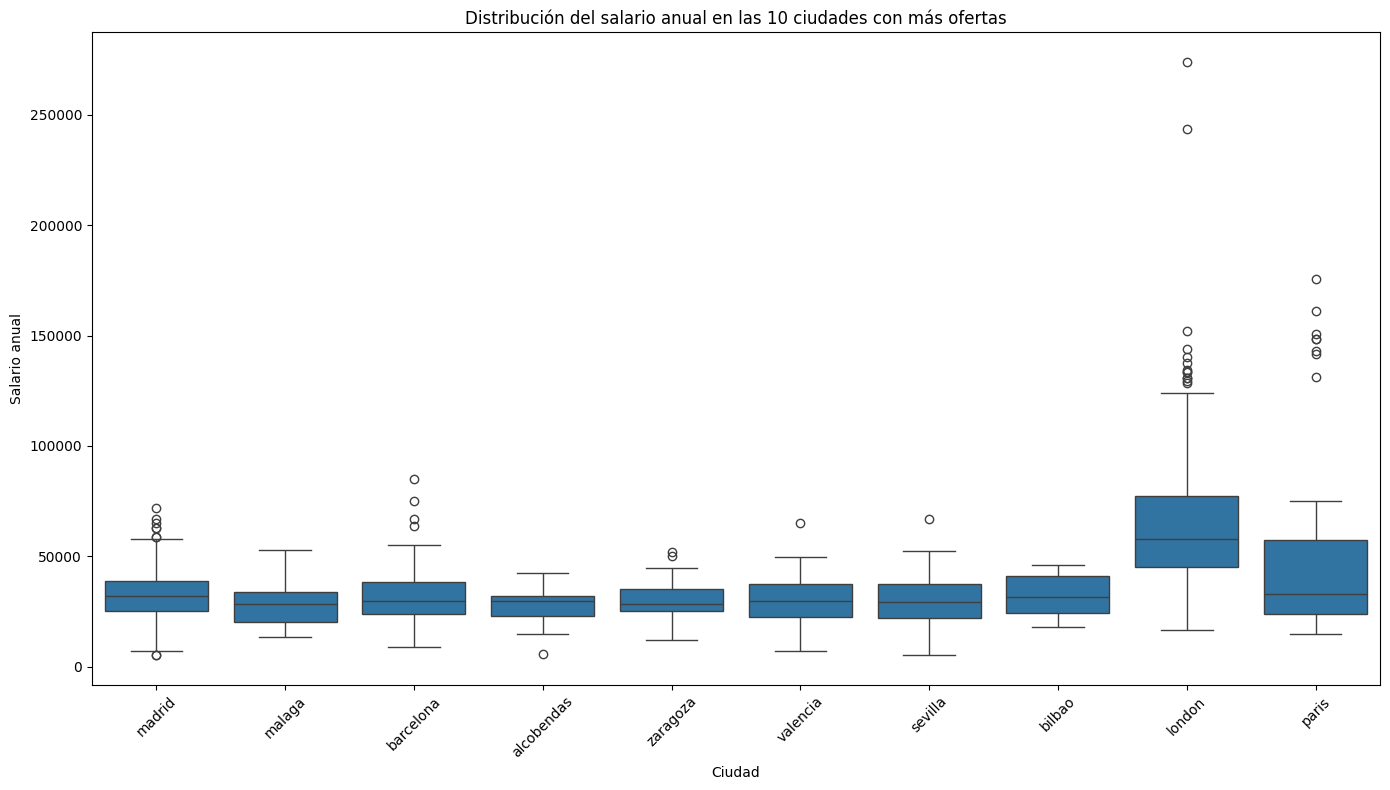

In [ ]:


# Convertimos a float64 y eliminamos nulos en annual_salary
# para compatibilidad con seaborn — ciudades sin salario rompen el cálculo de posiciones.
df_top['annual_salary'] = df_top['annual_salary'].astype(float)
df_top = df_top.dropna(subset=['annual_salary'])

# Boxplot
plt.figure(figsize=(14,8))
sns.boxplot(x='city', y='annual_salary', data=df_top)
plt.xticks(rotation=45)
plt.ylabel("Salario anual")
plt.xlabel("Ciudad")
plt.title("Distribución del salario anual en las 10 ciudades con más ofertas")
plt.tight_layout()
plt.show()

**Gráfico 1 Distribución del salario anual por ciudad en España (Top 10)**

Descripción

El gráfico presenta la distribución del salario anual en las diez ciudades para las que disponemos más ofertas mediante diagramas de caja (boxplots). Para cada ciudad se observa la mediana salarial, el rango intercuartílico (IQR), la dispersión de los datos y la presencia de valores atípicos. Las ciudades incluidas son Madrid, Valencia, Barcelona, A Coruña, Alcobendas, Sevilla, Zaragoza, Bilbao, París y Londres.

Análisis (enfoque técnico y comparativo)

En primer lugar, llama bastante la atención la diferencia entre los datos de las ciudades españolas y los de Londres y París. Se observa que, en ambas ciudades, los datos que se encuentran dentro del IQR superan a los de España, especialmente en el caso de Londres, con un Q1 ya superior a prácticamente el Q3 de las ciudades españolas. París, en cambio, tiene una mayor dispersión, con un Q1 a la altura de las ciudades españolas, pero un Q3 más cercano a Londres, y un Q2 más cercano al Q1 que al Q3. Los datos están fuertemente escorados a la derecha, con muchos outliers superiores, lo que indica una gran desigualdad en los datos disponibles de París.

En cuanto a las ciudades españolas, Madrid y Barcelona presentan las medianas salariales más elevadas, junto con una mayor dispersión, reflejada en rangos intercuartílicos más amplios y una elevada cantidad de valores atípicos superiores. Esto indica la coexistencia de salarios medios con puestos de alta remuneración, característicos de mercados laborales grandes y diversificados.

Ciudades como Valencia y Zaragoza muestran una dispersión intermedia, con medianas ligeramente inferiores a Madrid y Barcelona, pero con colas superiores relevantes, lo que sugiere la presencia de nichos laborales bien remunerados, aunque menos frecuentes.

La presencia de numerosos outliers positivos en varias ciudades (especialmente en las ciudades de mayor tamaño) introduce una asimetría positiva en la distribución, reforzando la idea de que la media salarial puede verse distorsionada, siendo la mediana un indicador más robusto para el análisis comparativo.

In [ ]:
#Hacemos ahora una representación de las ofertas por sector, con los datos que ya hemos tratado

fig_sector = px.histogram(
    df,
    x="job_sector",
    color="job_sector",
    title="Distribución de ofertas por sector",
    labels={"job_sector": "Categoría", "Recuento": "Recuento"})

fig_sector.update_layout(showlegend=False,
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Sector",
    yaxis_title="Número de ofertas",
    template="plotly_white",
    bargap=0.25)

fig_sector.show()

**Gráfico 2 Distribución por sector**

Descripción:

El gráfico muestra la distribución de las ofertas laborales según el sector de actividad, a partir de la asignación que hemos hecho previamente. Se observa una clara concentración de ofertas en "Other" y en "Software". En "Other" se engloban trabajos como técnicos y aquellos que, por ser muy generales, no pueden encuadrarse en otra categoría. En cambio, en "Software" estarían todos aquellos puestos relacionados puramente con programación.

En cuanto al resto de sectores ("Data", "Engineering", "PM" y "Executive"), es coherente que el número de puestos disminuya. Esto se debe a que los tres primeros casos son bastante especializados y a que, en particular en el caso de "Data", en el año 2022, todavía no habían llegado a profilerar como actualmente. Por último, como "Executive" solo contiene puestos de mayor responsabilidad, es comprensible que haya tan pocas ofertas (tan solo 100 en total).

In [ ]:
fig_salary = px.histogram(
    df,
    x="annual_salary",
    nbins=100,
    title="Histograma de salarios",
    labels={"annual_salary": "Salario anual", "count": "Número de ofertas"})

fig_salary.update_traces(marker=dict(line=dict(color="black", width=1)))

fig_salary.update_layout(title_font_size=22, title_x=0.5, template="plotly_white")

fig_salary.show()

**Gráfico 3: Distribución de salarios anuales**

Descripción:

El histograma representa la distribución de los salarios anuales en nuestro dataset. La mayor densidad de observaciones se concentra entre los 30 000 y 35 000 euros anuales, con una distribución asimétrica positiva, con un número aún relevante de 55 000 a 105 000, pero donde también se pueden observar ciertas ofertas, en un volumen mucho más reducido, con un salario superior a 105 000.

Todo esto indica la presencia de salarios altos atípicos (outliers) que elevan la media respecto a la mediana, por lo que la mediana salarial sería más representativa del ingreso típico que la media.

### 7.3 Gráficos de barras y temporales

#### 7.3.1  Ciudades con más ofertas

In [ ]:
#Vamos a preparar un gráfico de barras con las ciudades con más ofertas
df_10_cities = df["city"].value_counts().head(10).reset_index()

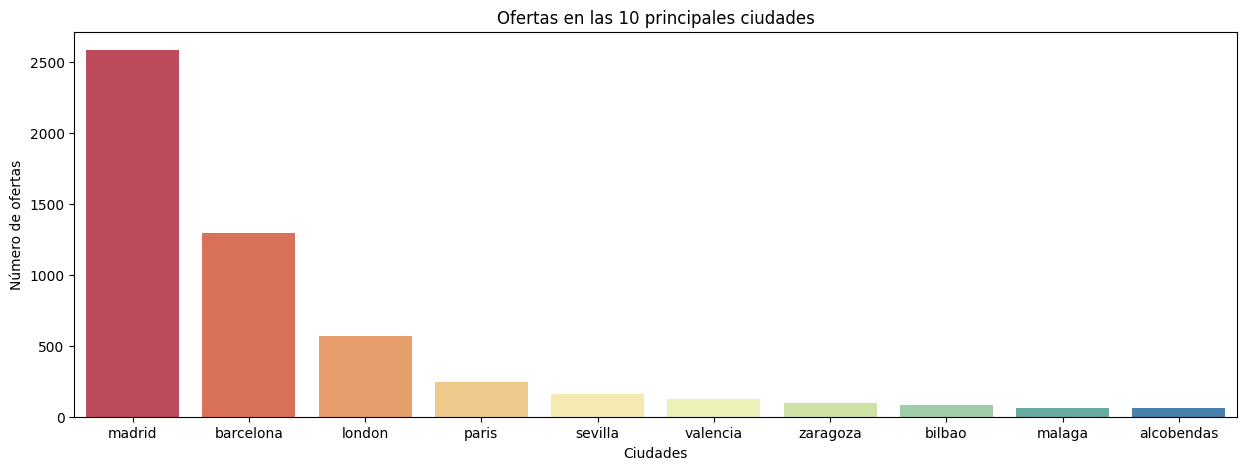

In [ ]:
#Preparamos ahora el gráfico, primero con Seaborn
plt.figure(figsize=(15,5))

sns.barplot(x="city", y="count", hue="city", data=df_10_cities, palette="Spectral", legend=False)
plt.xlabel("Ciudades")
plt.ylabel("Número de ofertas")
plt.title("Ofertas en las 10 principales ciudades")
plt.show();

In [ ]:
#Añadimos una función para mostrar los porcentajes de cada ciudad:
total_ofertas = df.shape[0]

#Y creamos el gráfico en plotly
fig = px.bar(df_10_cities, y="city", x="count", text=[f"{v/total_ofertas*100:.1f}%"
          for v in df_10_cities["count"]],
             labels={"city": "Ciudades", "count":"Número de ofertas"}, width=1000, height=400)
fig.update_yaxes(autorange="reversed")
fig.update_layout(title="Ofertas en las 10 principales ciudades")
fig.update_traces(marker=dict(color="gold"))
fig.update_traces(textposition="auto")
fig.show()

**Gráfico 4: Número de ofertas en las 10 principales ciudades del dataset**

Descripción:

Constatamos que la gran mayoría de ofertas de todo nuestro dataset se concentran en Madrid y Barcelona, ya que, entre ambas, concentran más de la mitad de ofertas de España (de manera concreta, el 54,1%). No solo eso, el hecho de que, dentro de este top 10, aparezca también Alcobendas, nos indica que la concentración en Madrid es aún más alta.

Por otra parte, el porcentaje de ofertas de Londres y París también es relevante, de hecho, superior a la tercera ciudad española en el ranking (Sevilla). Estos datos ya se habían detectado previamente y fue precisamente por esto por lo que solo se conservaron los datos de Londres y París como ciudades extranjeras, por volumen de ofertas y por proximidad geográfica, lo que facilita que puedan captar trabajadores españoles.

En cuanto al resto de ciudades nacionales, el orden es similar al de las ciudades más pobladas de España.

De este modo, se puede extraer como conclusión final una elevada concentración de ofertas laborales, por un lado a nivel nacional, y por otro, a mayor escala, a nivel europeo.

#### 7.3.2  Presencialidad

In [ ]:
#Veamos ahora la presencialidad en las ofertas
df["remote"].value_counts()

,count
remote,
no publicado,2932
presencial,1875
hibrido,1360
remoto,817


In [ ]:
#Observamos que hay un número relevante de ofertas en híbrido y teletrabajo

#Agrupamos ahora por ciudad y por presencialidad
df_city_remote_counts = df.groupby(["city", "remote"]).size().reset_index(name="count")
df_city_remote_counts = df_city_remote_counts.sort_values("count", ascending=False)

In [ ]:
#Nos quedamos solo con Madrid y Barcelona, ya que tienen mucho más ofertas que el resto
#Y ayudará a las visualización de los datos
df_remote_top2 = df_city_remote_counts[df_city_remote_counts["city"].isin(["madrid", "barcelona"])]

In [ ]:
#Hacemos ahora un gráfico de barras con estos datos
presencialidad_por_ciudad = df_remote_top2.groupby('city')['count'].transform('sum')

fig2 = px.bar(df_remote_top2, x="city", y="count", color="remote",
title="Presencialidad en Madrid y Barcelona",
text=[f"{(fila["count"]/presencialidad_por_ciudad.loc[idx])*100:.1f}%"
      for idx, fila in df_remote_top2.iterrows()],
labels={"count": "Número de ofertas", "city": "Ciudad", "remote": "Presencialidad"},
barmode="stack", width=1000, height=500)

fig2.show()

**Gráfico 5: Presencialidad en Madrid y Barcelona**

Descripción:

Si bien no hay datos sobre un número relevante de ofertas, podemos observar diferencias claras entre ambas ciudades.

Así, mientras en Barcelona hay pocas ofertas en proporción en la modalidad de teletrabajo (7,7%), observamos que es bastante mayor en Madrid (21,8%). Hay pequeñas diferencias también entre presencial e híbrido, pero no tan altas, además, es cierto que la proporción de ofertas sin datos es bastante más elevada en Barcelona que en Madrid.

Por tanto, una conclusión es que, si bien Madrid aglutina un gran número de ofertas totales según el gráfico anterior (40,9%), un porcentaje nada desdeñable de estas ofertas (21,8%) es de teletrabajo, con lo que podrían considerarse como parte del total nacional sin limitarse a Madrid. Sin embargo, también es cierto que la categoría "híbrido" es la mayoritaria en ambas ciudades sin contar nulos, lo que indicaría una preferencia por esta modalidad en las ofertas analizadas.

#### 7.3.3  Empresas con más ofertas

In [ ]:
#A continuación, analizemos las empresas con más ofertas
top_20 = df["company_name"].value_counts().head(20).index
df_20_companies = (df[df["company_name"].isin(top_20)]
     .groupby(["company_name", "job_sector"]).size()
     .reset_index(name="count"))

In [ ]:
#Hacemos otro gráfico de barras con estos datos

fig = px.bar(df_20_companies, x="company_name", y="count", color="job_sector", color_discrete_sequence=px.colors.qualitative.G10,
labels={"company_name": "Empresa", "count":"Número de ofertas", "job_sector":"Categoría"},
              barmode="stack", width=1200, height=500)

fig.update_layout(title="Empresas con más ofertas y su sector",xaxis={"categoryorder":"total descending"})
fig.show()

**Gráfico 6: Empresas con más ofertas y su sector**

Descripción:

Las dos empresas con más ofertas (más de 100 en total) son "Michael Page" y "TD SYNNEX". "Michael Page" es una consultora de reclutamiento especializada en perfiles cualificados, por lo que es razonable que ocupe el primer puesto (y además será muy útil para obtener buenos datos de acuerdo al guion de trabajo), mientras que "TD SYNNEX" es una empresa especializada en IT.

Si bien el grupo mayoritario en ambas empresas es "Other", también es cierto que poseen, comparativamente, un número algo más alto de ofertas de "Data" (más de 10 cada una) que casi todas las demás, salvo por "Ibermatica", que es precisamente la tercera empresa con más ofertas. Es llamativo además que "TD SYNNEX" tiene también unas cuantas ofertas en "Engineering", mientras que "Michael Page" posee 9 ofertas del grupo "Executive", del cual, recordemos, solo había 100 ofertas en total. Esto se explica por las características ya mencionadas de cada empresa.

En cuanto a las empresas que completan el top 5 (ibermatica, experis it y between technology), domina el grupo "Software", algo también comprensible por ser todas ellas empresas focalizadas en dicho sector.

#### 7.3.4 Categorías con los sueldos más altos

job_sector
Executive          77918.625
Project Mgmt    52131.154762
Data                 45933.4
Engineering     43041.806931
Other           36139.762562
Software        31510.041284
Name: annual_salary, dtype: Float64
Categoría con mayor sueldo: Executive
Salario medio: 77918.625


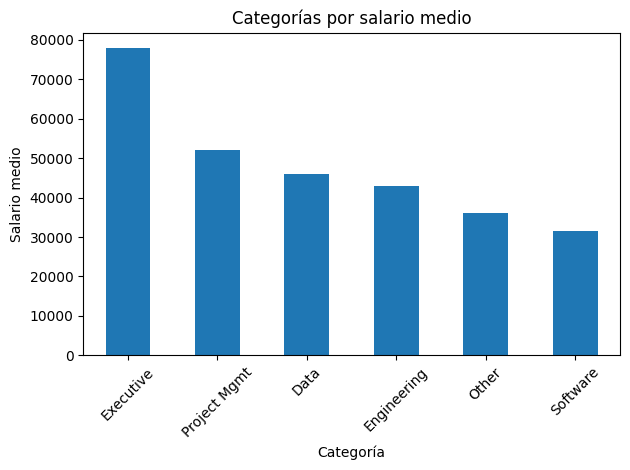

In [ ]:
# Agrupamos por categoría
salary_by_category = (
    df.groupby("job_sector")["annual_salary"]
      .mean()
      .sort_values(ascending=False)
)

# Categoría con mayor sueldo
top_category = salary_by_category.idxmax()
top_salary = salary_by_category.max()

# Mostrar sueldo por categoría
print(salary_by_category.head(6))

print("Categoría con mayor sueldo:", top_category)
print("Salario medio:", top_salary)

# Crear gráfica
plt.figure()
salary_by_category.plot(kind="bar")
plt.title("Categorías por salario medio")
plt.xlabel("Categoría")
plt.ylabel("Salario medio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Pasamos ahora a plotly

fig = px.bar(salary_by_category.reset_index(), x="job_sector", y="annual_salary",
labels={"job_sector": "Sector", "annual_salary":"Sueldo medio"},
              barmode="stack", width=900, height=500)

fig.update_layout(title="Sueldo medio por sector",xaxis={"categoryorder":"total descending"})
fig.show()

**Gráfico 7: Sueldo medio por sector**

Descripción:

El gráfico muestra diferencias claras en el sueldo medio según el sector profesional. Como es esperable, la categoría “executive” presenta el salario medio más elevado, situándose notablemente por encima del resto de sectores. Esto es coherente con el tipo de posiciones que engloba, generalmente asociadas a mayor responsabilidad estratégica y toma de decisiones.

En un segundo nivel se encuentran “engineering” y “pm” (project management), ambos con salarios medios muy similares entre sí y claramente superiores al promedio general del dataset. Estas categorías agrupan perfiles técnicos especializados y roles de coordinación con alto valor en el mercado laboral, lo que explica su posicionamiento.

El sector “data” aparece ligeramente por debajo de engineering y pm, aunque mantiene un nivel salarial competitivo y superior a otras categorías. Esto refleja la consolidación del área de datos como campo técnico bien remunerado, aunque todavía algo por detrás de posiciones más senior o estratégicas.

En la parte inferior del gráfico se sitúan “other” y “software”, con los salarios medios más bajos dentro de la clasificación. En el caso de “software”, este resultado puede estar influido por la heterogeneidad interna de la categoría, que incluye perfiles de distinto nivel y especialización. Además, si esta categoría concentra un mayor volumen de ofertas en mercados con salarios más moderados, el promedio puede verse reducido.

En conjunto, el gráfico confirma una jerarquía salarial coherente con la estructura habitual del mercado laboral tecnológico: posiciones ejecutivas en el extremo superior, perfiles técnicos especializados en el rango intermedio y categorías más amplias o heterogéneas en niveles salariales inferiores.

#### 7.3.5 Estacionalidad

In [ ]:
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

df['mes'] = df['publish_date'].dt.month

meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

df['mes_nombre'] = df['mes'].map(meses_es)

In [ ]:
estacionalidad = (
    df
    .groupby('mes_nombre')
    .size()
    .reset_index(name='num_ofertas')
)

In [ ]:
orden_meses = [
    'Enero','Febrero','Marzo','Abril','Mayo','Junio',
    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'
]

estacionalidad['mes_nombre'] = pd.Categorical(
    estacionalidad['mes_nombre'],
    categories=orden_meses,
    ordered=True
)

estacionalidad = estacionalidad.sort_values('mes_nombre')
estacionalidad

,mes_nombre,num_ofertas
4,Marzo,9
0,Abril,1
3,Junio,650
2,Julio,4168
1,Agosto,2154
5,Septiembre,2


In [ ]:
estacionalidad['porcentaje'] = (
    estacionalidad['num_ofertas'] /
    estacionalidad['num_ofertas'].sum() * 100
).round(2)

estacionalidad

,mes_nombre,num_ofertas,porcentaje
4,Marzo,9,0.13
0,Abril,1,0.01
3,Junio,650,9.31
2,Julio,4168,59.68
1,Agosto,2154,30.84
5,Septiembre,2,0.03


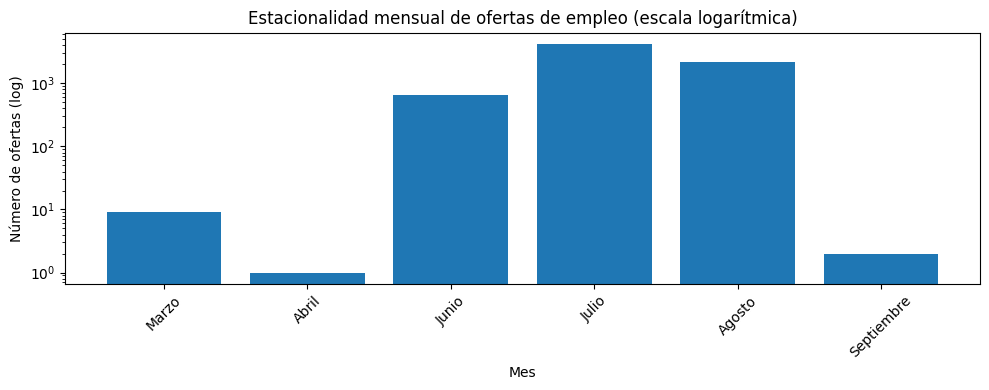

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(estacionalidad['mes_nombre'], estacionalidad['num_ofertas'])

plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Estacionalidad mensual de ofertas de empleo (escala logarítmica)')
plt.xlabel('Mes')
plt.ylabel('Número de ofertas (log)')

plt.tight_layout()
plt.show()

**Gráfico 8: Estacionalidad de las ofertas**

Descripción:

Contrario a lo que podría parecer, se observa que el mayor volumen de ofertas se publica en los meses de junio a agosto, ambos inclusive, por lo que sí que hay estacionalidad en el periodo de publicación de ofertas. Esto puede deberse a que se usan estos meses para publicar ofertas y recibir CVs para poder comenzar a hacer entrevistas más adelante. Cabe recordar también que se incluyen ofertas de Londres, donde no hay tanto "parón" en agosto (sí es más el caso de París).

Un detalle importante a tener en cuenta es que desconocemos el momento en el que se han extraído los datos. Es posible que, al haber tantas ofertas en meses estivales, las ofertas se hayan extraído en los meses de agosto/septiembre.

## 8.Preguntas del caso de estudio

### 8.1 Número de ofertas en el dataset

In [ ]:
#Esta pregunta ya se ha respondido indirectamente, pero podemos responderla ahora de manera explícita:

print(f"El número de ofertas del dataset actual es de: {df.shape[0]}")

El número de ofertas del dataset actual es de: 6984


Recordemos que partimos de 10 000 ofertas en total, pero que, tras la limpieza de datos y la eliminación de los países que no nos interesaban, el número final resultante es de **6984 ofertas**.

### 8.2 Sueldo medio

In [ ]:
# Ya hemos hecho diversas exploraciones sobre el sueldo, como el histograma y el boxplot,
# pero vamos a calcular ahora la media. Hagamos primero la media sobre todo el conjunto:

print(f"El sueldo medio del dataset es de: {df['annual_salary'].mean():.2f} euros")

El sueldo medio del dataset es de: 37720.47 euros


In [ ]:
#Y ahora por país:

promedios = df.groupby('country_code')['annual_salary'].mean().round(2)
print(f"El sueldo medio, en euros, de cada país es de: {promedios.to_dict()}")

El sueldo medio, en euros, de cada país es de: {'es': 30101.52, 'fr': 47252.57, 'uk': 63447.14}


Constatamos, como ya hemos comentado anteriormente, que **el sueldo medio español se encuentra bastante por debajo** del de Francia y Reino Unido, de hecho, a pesar de ser el país con mayor volumen, es el único que se encuentra por debajo del sueldo medio total del dataset. Si bien es cierto que de Francia y Reino Unido nos hemos quedado únicamente con los datos de sus capitales, los datos de Madrid y Barcelona tampoco llegaban a equipararse a los de Francia, como vimos en el gráfico de boxplot y veremos de nuevo en la siguiente pregunta.
Vemos también cómo, en euros, el sueldo de **Reino Unido llega a duplicar el de España**.

Verificamos además que el **sueldo medio español es ligeramente superior a la media total nacional de 2022**, que se situaba en prácticamente 27 000 euros. Esta pequeña diferencia puede explicarse al alto volumen de ofertas del dataset en Madrid y Barcelona y a la elevada presencia de puestos tech.

### 8.3 Trabajos mejor pagados y dónde

In [ ]:
#Esta pregunta no la hemos respondido aún, aunque hemos explorado datos sobre empresas y sueldos. Veamos:

df.groupby('title')['annual_salary'].mean().sort_values(ascending=False).reset_index().head(20)

,title,annual_salary
0,ibcm controls vp,273780.0
1,senior java developer (sc),243360.0
2,(bruxelles) business analyst secteur bancaire,175500.0
3,data engineer aws senior / freelance,161200.0
4,aem solutions architect,152240.0
5,product owner (produit web) / freelance,150800.0
6,business analyst summit front - fixed income &...,148200.0
7,business analyst - summit front / freelance,148200.0
8,corporate legal counsel,144121.0
9,devops senior cloud/back end / freelance,143000.0


En general, estos datos se ajustan a lo que podríamos esperar como los más altos. Hay muchas ofertas para puestos de mucha responsabilidad (director, VP) y también senior. Predominan también las ofertas del sector tech y de datos, varias de ellas en relación a tecnología cloud (ingeniero de datos, arquitecto de soluciones...)

Resulta llamativo, eso sí, la presencia de diversas ofertas freelance. Esto puede explicarse a que, a cambio de un contrato con menor seguridad que un fijo, la empresa puede ofrecer una mayor remuneración como aliciente.

In [ ]:
#Hagamos ahora la agrupación por ciudades:

df.groupby('city')['annual_salary'].mean().round(2).sort_values(ascending=False).reset_index().head(10)

,city,annual_salary
0,london,63447.14
1,sant joan de vilatorrada,57000.0
2,bruselas,54000.0
3,viladecavalls,50500.0
4,paris,47252.57
5,dischingen-eglingen,47000.0
6,tolosa,42500.0
7,villaviciosa de odon,42000.0
8,pallejà,42000.0
9,cantoria,41000.0


Un dato que podemos observar aquí es que, además de Londres y París, como esperábamos, hay muchas ofertas en localidades que se encuentran en la periferia catalana o incluso madrileña.

Sin embargo, también vemos que aparecen datos de Bruselas y de una localidad alemana, que no deberían estar en el ranking por haber eliminado ya datos de dichos países, por lo que los analizaremos para saber si ha habido algún problema en el etiqutado del país.

In [ ]:
#Antes de continuar, veamos los datos de Bruselas y de Dischingen-Eglingen

df_bruselas = df[df['city'] == "bruselas"]
df_bruselas

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date,mes,mes_nombre
2122,es,analista programador java (bruselas),informatica y telecomunicaciones,Data,abde business consulting,bruselas,NaN,contrato indefinido,completa,technical,presencial,50000.0,58000.0,54000,eur,2022-07-13,7,Julio


In [ ]:
df_dischingen_eglingen = df[df['city'] == "dischingen-eglingen"]
df_dischingen_eglingen

,country_code,title,job_category,job_sector,company_name,city,provincia,contract_type,workday,position_level,remote,salary_min,salary_max,annual_salary,salary_currency,publish_date,mes,mes_nombre
1867,es,informatico para integracion de sistemas (m/f)...,informatica y telecomunicaciones,Software,camara comercio alemana,dischingen-eglingen,NaN,contrato indefinido,completa,technical,presencial,46000.0,48000.0,47000,eur,2022-07-14,7,Julio


In [ ]:
# Parece que en ambos casos puede haber un tipo de acuerdo para haber publicado
# la oferta en España, sin embargo, el sueldo y la ciudad efectiva del destino pertenenecen
# al extranjero, por lo que eliminaremos estos datos del dataset.

df = df[~df["city"].str.contains("dischingen-eglingen|bruselas", case=False, na=False)]

In [ ]:
# Hecho todo esto, vamos a distinguir entre ciudades con al menos 20 ofertas para
# que los datos de media que obtengamos sean más representativos y así evitar que
# aparezcan en el ranking localidades con una sola oferta.

ciudades_mayor_sueldo = df.groupby("city").agg(sueldo_medio=("annual_salary", "mean"), total_ofertas=("title", "count"))
ciudades_mas_ofertas = ciudades_mayor_sueldo[ciudades_mayor_sueldo["total_ofertas"] >= 20]
top_10_ciudades = ciudades_mas_ofertas.sort_values(by="sueldo_medio", ascending=False).reset_index().head(10)

top_10_ciudades

,city,sueldo_medio,total_ofertas
0,london,63447.141328,566
1,paris,47252.568182,246
2,madrid,32454.148607,2583
3,cornellà de llobregat,31875.0,37
4,bilbao,31800.0,81
5,barcelona,31381.799308,1296
6,tres cantos,30976.470588,52
7,zaragoza,30314.285714,99
8,valencia,30275.918367,125
9,sevilla,29433.333333,162


Vemos que, tras Londres y París, aparecen de nuevo bastantes localidades de la periferia de Madrid y Barcelona, pudiéndose deber a la presencia de focos industriales en dichos lugares. Un dato interesante es que Bilbao tiene un sueldo medio ligeramente superior a Barcelona, algo atribuible al alto nivel de vida en País Vasco. Para finalizar, en la parte baja de este top 10, tenemos precisamente el resto de ciudades con mayor población del país.

Todo esto confirma lo ya expuesto anteriormente: el mayor sueldo medio se concentra en las ciudades con mayor población, aunque, un matiz muy importante es que la diferencia tampoco es significativa: la diferencia entre Madrid (la ciudad con mayor sueldo medio de España) y Sevilla (la última del ranking) es solo 3000 euros brutos anuales.

### 8.4 Empresas en ambos datasets

In [ ]:
# En esta pregunta se nos pide detectar si hay empresas que coincidan en ambos datasets.
# Por tanto, deberemos cargar el csv limpio de los datos scrapeados. Como el otro notebook
# ya está listo y exportado, podemos cargarlo en este notebook para ejecutar los análisis pertinentes.

# ruta = '/content/drive/MyDrive/Oferta-empleos(1)/ofertas-empleo (1).csv'
# df = pd.read_csv(ruta)

CSV_ID_SCRAP = "1wu3LdTo0-Qz8T1ps4uU_43Q7m4LcOC5Q"

url_scrap = f"https://drive.google.com/uc?export=download&id={CSV_ID_SCRAP}"

df_scrap = pd.read_csv(url_scrap, encoding="utf-8")

In [ ]:
#Mostramos el nuevo df para verificar que los datos son correctos:

df_scrap.head()

,city,country_code,job_title,company_name,job_sector,annual_salary,salary_min,salary_max,contract_type,workday,work_mode,publish_date,source
0,london,uk,av technician,peregrine,other,42958.0,42958.0,42958.0,permanent,completa,NaN,2026-01-15,adzuna
1,london,uk,aircraft engine technician,shorterm group,other,77283.0,77283.0,77283.0,permanent,completa,NaN,2026-01-15,adzuna
2,london,uk,welder / fabricator (mig / tig),ernest gordon recruitment limited,other,43654.0,41860.0,45448.0,permanent,completa,NaN,2026-01-15,adzuna
3,london,uk,fire alarm commissioning engineer,hp4 recruitment ltd,engineering,53475.0,51750.0,55200.0,permanent,completa,NaN,2026-01-15,adzuna
4,london,uk,fire alarm service engineer,hp4 recruitment ltd,engineering,44850.0,43700.0,46000.0,permanent,completa,NaN,2026-01-15,adzuna


In [ ]:
# Buscamos si hay coincidencias con una función de boleanos
coincidencias = df[df["company_name"].isin(df_scrap["company_name"])]

print(f"Se han encontrado {len(coincidencias)} coincidencias.")

Se han encontrado 1043 coincidencias.


In [ ]:
# Vemos que aparecen muchos resultados coincidentes, lo que nos resultará muy
# útil para poder hacer comparaciones más adelante. Veamos ahora cuáles son las
# empresas que más coinciden

# Guardamos los resultados de cada df en una variables
c1 = df["company_name"].value_counts()
c2 = df_scrap["company_name"].value_counts()

# Creamos una tabla comparativa uniendo los resultados
comparativa = pd.DataFrame({"Archivo_1": c1, "Archivo_2": c2})
comparativa["Total"] = comparativa["Archivo_1"] + comparativa["Archivo_2"]

# Filtramos para quedarnos solo con las coincidencias.
# Como vimos que había muchas coincidencias, utilizamos 5 como umbral y evitar que
# aparezcan empresas con pocos resultados en un df
solo_coincidencias = comparativa[(comparativa["Archivo_1"] > 5) & (comparativa["Archivo_2"] > 5)]

# Ordenamos las empresas por número total
print(solo_coincidencias.sort_values(by="Total", ascending=False))


                             Archivo_1  Archivo_2  Total
company_name                                            
michael page                     121.0       19.0  140.0
accenture                         17.0      107.0  124.0
sopra steria                      22.0      100.0  122.0
second window                      8.0      103.0  111.0
pss                               49.0        6.0   55.0
talan                             24.0       30.0   54.0
aubay                             26.0       26.0   52.0
deloitte                          15.0       27.0   42.0
alten                             30.0        6.0   36.0
sgs                               24.0       11.0   35.0
grupo digital                     26.0        8.0   34.0
veolia españa                     11.0       12.0   23.0
gmv                               10.0        8.0   18.0
krell consulting & training       10.0        8.0   18.0
grupo ns                          11.0        6.0   17.0


Como resultado, hay **15 empresas en total con al menos 5 ofertas** en ambos datasets, si bien en los cinco primeros casos hay una predominancia en uno de los dos datasets, mientras que empresas como Talen y Aubay sí que están muy repartidas entre ambas fuentes.

En cuanto a la tipología de las empresas, podemos observar que muchas de ellas son **consultoras y, además, francesas**, lo que tiene sentido debido a que hemos incluido París en nuestro análisis. Muchas de estas consultoras pertenecen, a su vez, al sector tecnológico, lo que también es comprensible debido a las ofertas a las que hemos dado prioridad. Esto nos resultará muy útil de analizar en Power BI teniendo en cuenta el guion del que partimos.

### 8.5 Empresas con mejores salarios

In [ ]:
# En este notebook, hemos podido ver las empresas con mayor número de ofertas,
# pero no las que ofrecen mejores salarios. Hagamos dicho cálculo a continuación:

df.groupby('company_name')['annual_salary'].mean().round(2).sort_values(ascending=False).reset_index().head(10)

,company_name,annual_salary
0,accenture,243360.0
1,bk consulting,175500.0
2,teolia,150800.0
3,micropole,148633.33
4,nexoris,148200.0
5,careers at tide,144121.0
6,vaticle,140400.0
7,insightsoftware,137546.0
8,aubay uk,134550.0
9,content square,133451.0


In [ ]:
# Hagamos ahora el mismo cálculo restringiendo de nuevo por ciudades con un número
# representativo (tomamos un umbral de 10 ofertas debido a que en el top 10 vimos
# que había empresas con al menos 30 ofertas aproximadamente):

In [ ]:
empresas_mayor_sueldo = df.groupby("company_name").agg(sueldo_medio=("annual_salary", "mean"), total_ofertas=("title", "count"))
empresas_mas_ofertas = empresas_mayor_sueldo[empresas_mayor_sueldo["total_ofertas"] >= 10]
top_10_empresas = empresas_mas_ofertas.sort_values(by="sueldo_medio", ascending=False).reset_index().head(10)

top_10_empresas

,company_name,sueldo_medio,total_ofertas
0,accenture,243360.0,17
1,netcentric,88550.4,23
2,microsoft,85995.0,12
3,salesforce,82704.6,14
4,boston consulting group,79786.0,24
5,michael page,79303.9,121
6,alibaba,77378.0,15
7,capgemini invent,75452.7,10
8,capgemini,68743.125,54
9,capco,64450.730769,26


Los resultados obtenidos son muy interesantes. A pesar de que hemos ampliado el umbral de ofertas, observamos que **Accenture** se mantiene en el ranking, y con una diferencia aún más pronunciada con las demás empresas. Esto constata lo ya visto en el paso previo, pero, además, comprobamos que no se debe a una única oferta potente. Al tener ya 17 ofertas, podemos afirmar que es una empresa que ofrece de forma constante sueldos muy superiores a los demás. Esto se puede atribuir a que se trata de una **consultora especializada en puestos tecnológicos**, que, como ya hemos visto, se trata de un sector con sueldos bastante elevados.

A continuación tenemos otras empresas tecnológicas y, después **Michael Page**. Esta es una empresa que vale la pena comentar con mayor detalle. Como ya comentamos anteriormente, es la empresa que tenía más ofertas de todo el dataset, y, aun así, aparece también en este ranking. Esto se explica a algo que ya se ha comentado también, y es la **especialización en sectores cualificados de esta empresa de reclutamiento**. En el resto del ranking predominan, de nuevo, empresas con alto peso tecnológico.

In [ ]:
# Por último, hagamos ahora una agrupación pero limitada ahora a España, ya que
# ya sabemos que las escalas salariales divergen bastante entre países.

In [ ]:
empresas_mayor_sueldo_es = df[df["country_code"] == "es"].groupby("company_name").agg(sueldo_medio=("annual_salary", "mean"), total_ofertas=("title", "count"))
empresas_mas_ofertas_es = empresas_mayor_sueldo_es[empresas_mayor_sueldo_es["total_ofertas"] >= 10]
top_10_empresas_es = empresas_mas_ofertas_es.sort_values(by="sueldo_medio", ascending=False).reset_index().head(10)

top_10_empresas_es

,company_name,sueldo_medio,total_ofertas
0,adevinta,53000.0,11
1,michael page,45000.0,87
2,agio global technology,42600.0,11
3,izertis,40750.0,14
4,hubtalent,40375.0,11
5,tecdata engineering,39125.0,10
6,consultia it,38466.666667,18
7,fed it,38000.0,18
8,metrica consulting,37875.0,15
9,oxigent technologies,37625.0,13


Comprobamos cómo vuelve a aparecer Michael Page, con un sueldo bastante inferior, pero con un porcentaje elevado de ofertas de su total (87 de 121).

Sin embargo, el puesto superior lo ocupa "Adevinta", que es una empresa formada por marcas como fotocasa o infojobs. Esta elevada presencia digital explica sus sueldos altos. En cuanto al resto del ranking, constatamos, una vez más, que predomina el sector tecnológico, además de una consultora (Metrica).

### 8.6 Empresas con más publicaciones y sector (datos scrapeados)

Esta pregunta aparece respondida en el [apartado 4.3.3](https://colab.research.google.com/drive/1RUpOvIqzJ79nbtSk5hT17WytSaYAjunW#scrollTo=oR0KHi_MgzwP) del notebook perteneciente a los datos scrapeados.

### 8.7 Estacionalidad

Esta pregunta sí se ha respondido ya exhaustivamente en el [apartado 7.3.5](https://colab.research.google.com/drive/1OeIOKcvBiIVBqPKD2gJbNFTd6BOWotPL#scrollTo=S7a1RQnueq4V) de este notebook con un gráfico de barras comentado, por lo que no es necesario volver a responderla.

### 8.8 Ciudades o regiones con más ofertas

Esta pregunta también aparece ya detallada en el [apartado 7.3.1](https://colab.research.google.com/drive/1OeIOKcvBiIVBqPKD2gJbNFTd6BOWotPL#scrollTo=WpYwzeBGdsKc).

### 8.9 Comparativa salarial entre ambos datasets

In [ ]:
# Para finalizar, aunque no se pida explícitamente, vamos a hacer un análisis:
# del salario medio del dataset con los datos scrapeados:

print(f"El sueldo medio del dataset de datos scrapeados es de: {df_scrap['annual_salary'].mean():.2f} euros")

El sueldo medio del dataset de datos scrapeados es de: 64517.48 euros


In [ ]:
#Y ahora por país:

promedios = df_scrap.groupby('country_code')['annual_salary'].mean().round(2)
print(f"El sueldo medio, en euros, de cada país es de: {promedios.to_dict()}")

El sueldo medio, en euros, de cada país es de: {'es': 56227.69, 'fr': 48602.0, 'uk': 71875.25}


Las conclusiones son muy interesantes. En comparación con los datos del dataset proporcionado, se observa que:

  - Los datos de **España son muy superiores**, llegando a casi duplicarse (de 30.101,52 a 56.227,69 euros).

  - En **Francia**, en cambio, las cifras pertenecen sin **apenas cambios**.

  - En **Reino Unido hay un pequeño incremento**, de 63.447,14 a 71.875,25 euros.

In [ ]:
#Si hacemos el cálculo para la mediana:

print(f"La mediana del sueldo del dataset es de: {df_scrap['annual_salary'].median():.2f} euros")

La mediana del sueldo del dataset es de: 57500.00 euros


Observamos que es **bastante inferior a la media**, y en línea con el sueldo medio de España. Esto se debe a que, como se muestra en los gráficos de boxplot del otro notebook, tenemos muchos **outliers altos** que "empujan" la media a valores más altos.

No debemos ignorar, además, que los datos scrapeados contenían un
**alto porcentaje de valores sin información** en el sueldo. Esto nos puede llevar a la conclusión de que, si bien el valor de España es muy alto, es posible que se vea afectado por esta circunstancia y que las ofertas con sueldos más bajos no aparezcan publicados. De hecho, recordemos que en Francia se tuvieron que corregir varias ofertas con sueldo por hora correspondientes a sueldos con menor remuneración, lo que puede explicar que el sueldo apenas haya variado en dicho país. Por tanto, este aumento tan pronunciado en España no puede tomarse de manera literal, sino teniendo en cuenta estas circunstancias.

## 9.Preparación final para la exportación del CSV

Una vez finalizada la limpieza y el análisis exploratorio de los datos, podemos exportar nuestro dataset a un CSV para trabajar ya con él en Power BI y elaborar nuestro dashboard. Este proceso sigue un orden lógico ya, que al tratar los datos previamente en este notebook, lo tendremos lo más preparado posible en Power BI y evitaremos trabajo duplicado. En caso de que se detecten nuevos datos que se deban tratar, se volverá preferiblemente a este notebook, a no ser que se trate de algo muy puntual.

### 9.1 Eliminación de las columnas "position_level", "mes" y "mes_nombre"

In [ ]:
# "position_level" se eliminará debido a que no ha sido posible extraer esta información
# de los datos scrapeados. Se eliminará en este paso porque es una columna que nos
# ha aportado información relevante en la parte de la limpieza y del EDA, pero, al
# no ser posible cruzar los datos, se eliminará para el CSV final que se usará en Power BI.
# En cuanto a "mes" y "mes_nombre", se usaron únicamente para la estacionalidad, pero es
# información que se calculará con las funciones de calendario de Power BI.

df = df.drop(columns=["position_level", "mes", "mes_nombre"])

In [ ]:
# Renombrar remote → work_mode y title →  job_title
df.rename(columns={
    'remote': 'work_mode',
    'title': 'job_title'
}, inplace=True)

# Crear source
df['source'] = 'Pontia'

# Estandarización de country_code a mayúsculas para coherencia visual en el dashboard.
# Se aplica al final para no romper los filtros anteriores que usan 'es', 'uk', 'fr' en minúscula.
df['country_code'] = df['country_code'].str.upper()

# Schema final
columnas_finales = ['city', 'country_code','job_title','company_name', 'job_sector','annual_salary', 'salary_min',
                    'salary_max', 'contract_type', 'workday', 'work_mode',
                    'publish_date', 'source']

df = df[columnas_finales]
print(df.columns.tolist())

['city', 'country_code', 'job_title', 'company_name', 'job_sector', 'annual_salary', 'salary_min', 'salary_max', 'contract_type', 'workday', 'work_mode', 'publish_date', 'source']


In [ ]:
df.head(5)

,city,country_code,job_title,company_name,job_sector,annual_salary,salary_min,salary_max,contract_type,workday,work_mode,publish_date,source
0,madrid,ES,tecnico gestion de la demanda,atento españa - estructura,Other,<NA>,NaN,NaN,contrato indefinido,completa,hibrido,2022-07-12,Pontia
1,madrid,ES,java - springboot - proyecto estable - teletra...,agio global technology,Software,42500,40000.0,45000.0,contrato indefinido,completa,remoto,2022-07-12,Pontia
2,madrid,ES,consultor sap hana ingles alto (remoto),airon sistemas s.l.,Other,28500,27000.0,30000.0,contrato indefinido,completa,remoto,2022-07-12,Pontia
3,madrid,ES,android developer. ingles alto. 100% remoto,modis,Software,<NA>,NaN,NaN,contrato indefinido,completa,remoto,2022-07-12,Pontia
4,madrid,ES,analista funcional temporal,atento españa - estructura,Data,25500,24000.0,27000.0,contrato indefinido,completa,hibrido,2022-07-12,Pontia


Verificamos que todas las columnas son las correctas.
Avanzamos al siguiente y último paso para exportar nuestro csv.

### 9.2 Exportación del CSV

El contenido de esta celda se ha eliminado para poder incluirlo en el portfolio sin la exportación del archivo y sin incluir las rutas de destino del archivo original.